In [1]:
import pandas as pd 

df = pd.read_csv('store-sales-time-series-forecasting/train.csv')

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [3]:
'''
import numpy as np
df['time'] = np.arange(len(df.index))
'''

# using DeterministicProcess instead of numpy helps navigate some tricky cases
# a deterministic series is not random or completely determined like trend and 
from statsmodels.tsa.deterministic import DeterministicProcess

dp = DeterministicProcess(
    index=df.index,      # dates from the training data
    constant=True,       # dummy feature for the bias (y_intercept)
    order=1,             # the time dummy (trend)
    drop=True,           # drop terms if necessary to avoid collinearity
)
# `in_sample` creates features for the dates given in the `index` argument
X = dp.in_sample()

X.head()

,const,trend
0,1.0,1.0
1,1.0,2.0
2,1.0,3.0
3,1.0,4.0
4,1.0,5.0


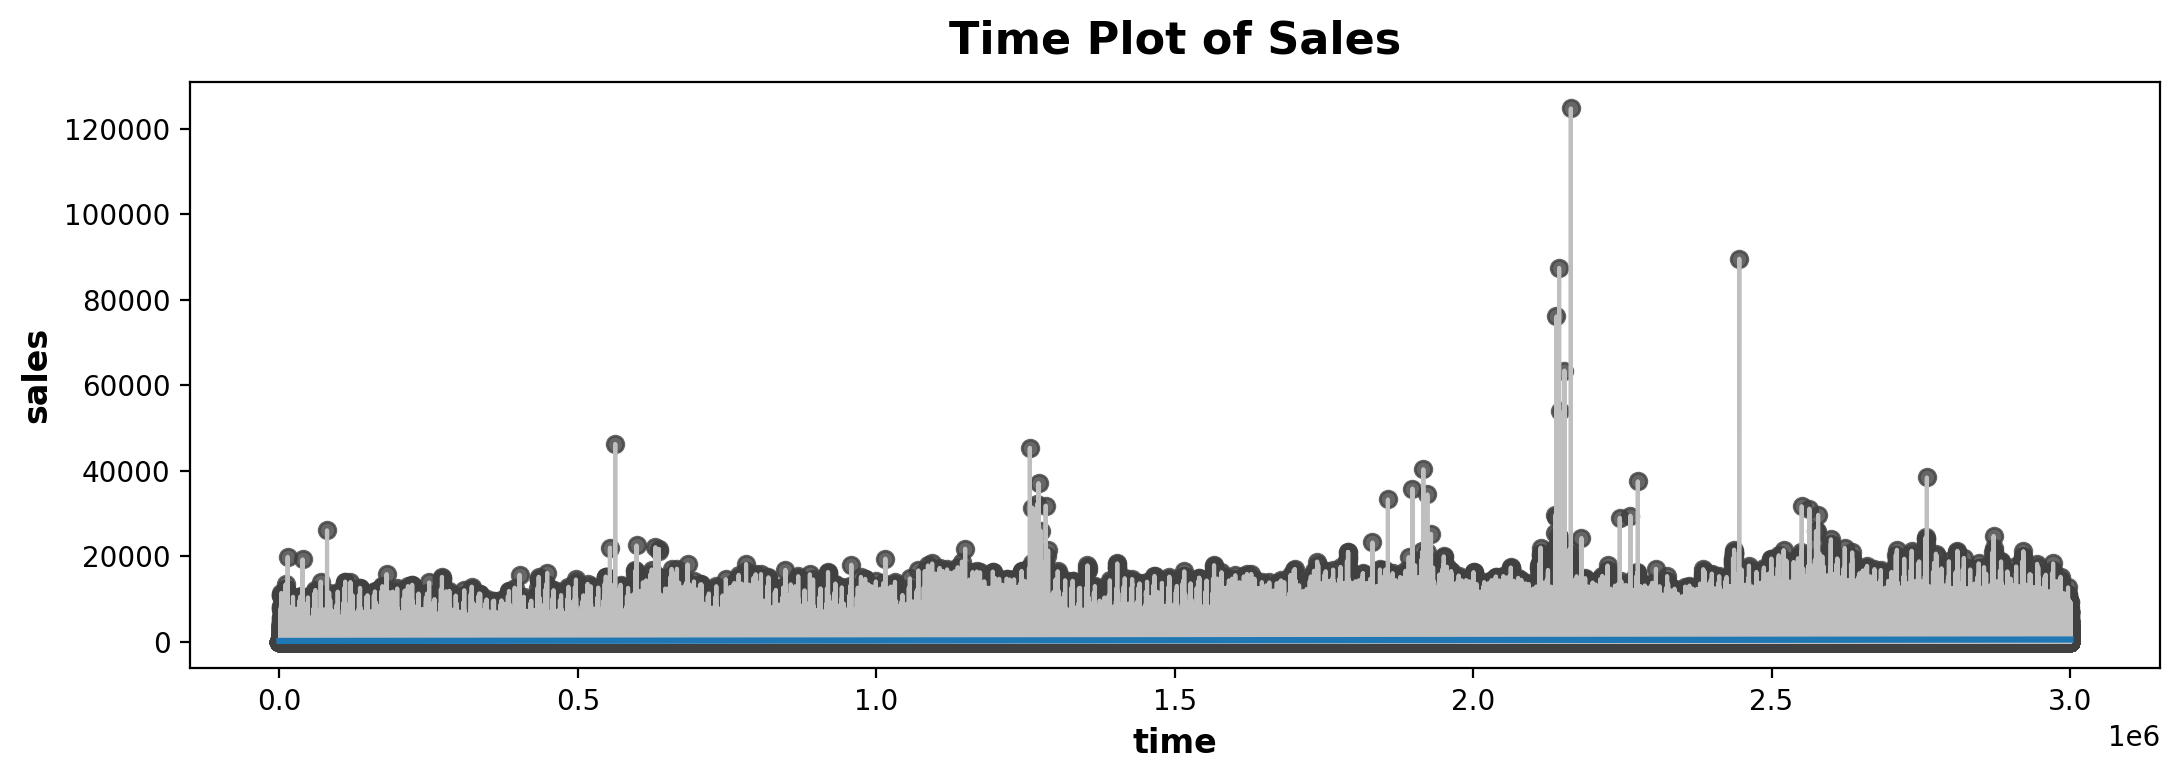

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots()
ax.plot('time', 'sales', data=df, color='0.75')
ax = sns.regplot(x='time', y='sales', data=df, ci=None, scatter_kws=dict(color='0.25'))
ax.set_title('Time Plot of Sales');

In [14]:
df['Lag_1'] = df['sales'].shift(1)
df = df.reindex(columns=['sales', 'Lag_1'])

df.head()

,sales,Lag_1
0,0.0,NaN
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


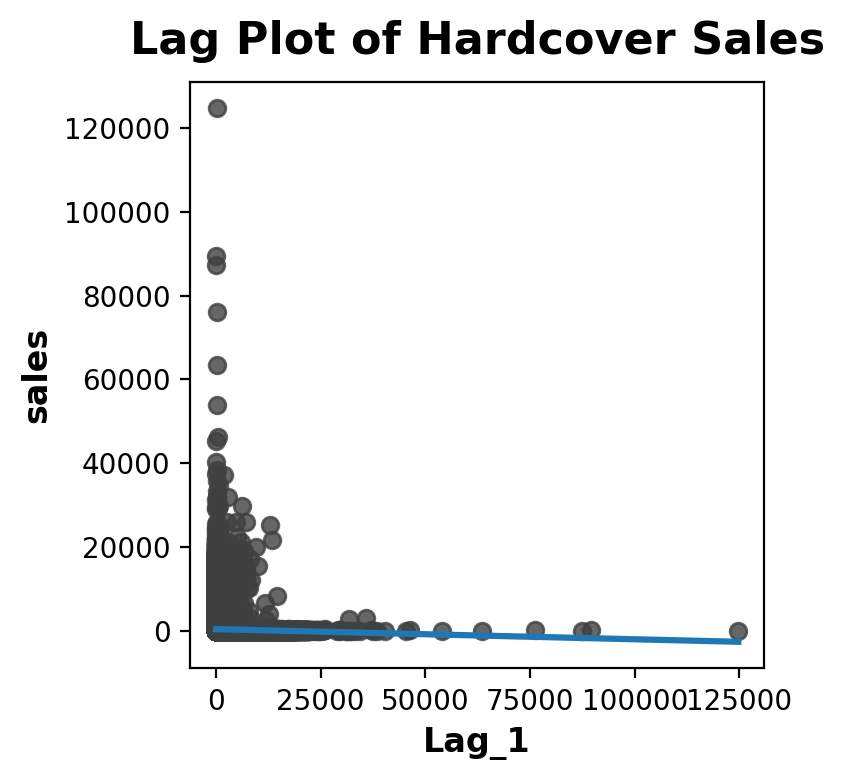

In [15]:
fig, ax = plt.subplots()
ax = sns.regplot(x='Lag_1', y='sales', data=df, ci=None, scatter_kws=dict(color='0.25'))
ax.set_aspect('equal')
ax.set_title('Lag Plot of Sales');

In [4]:
from sklearn.linear_model import LinearRegression

# Training data
X = df.loc[:, ['time']]  # features
y = df.loc[:, 'sales']  # target

# Train the model
model = LinearRegression()
model.fit(X, y)

# Store the fitted values as a time series with the same time index as
# the training data
y_pred = pd.Series(model.predict(X), index=X.index)

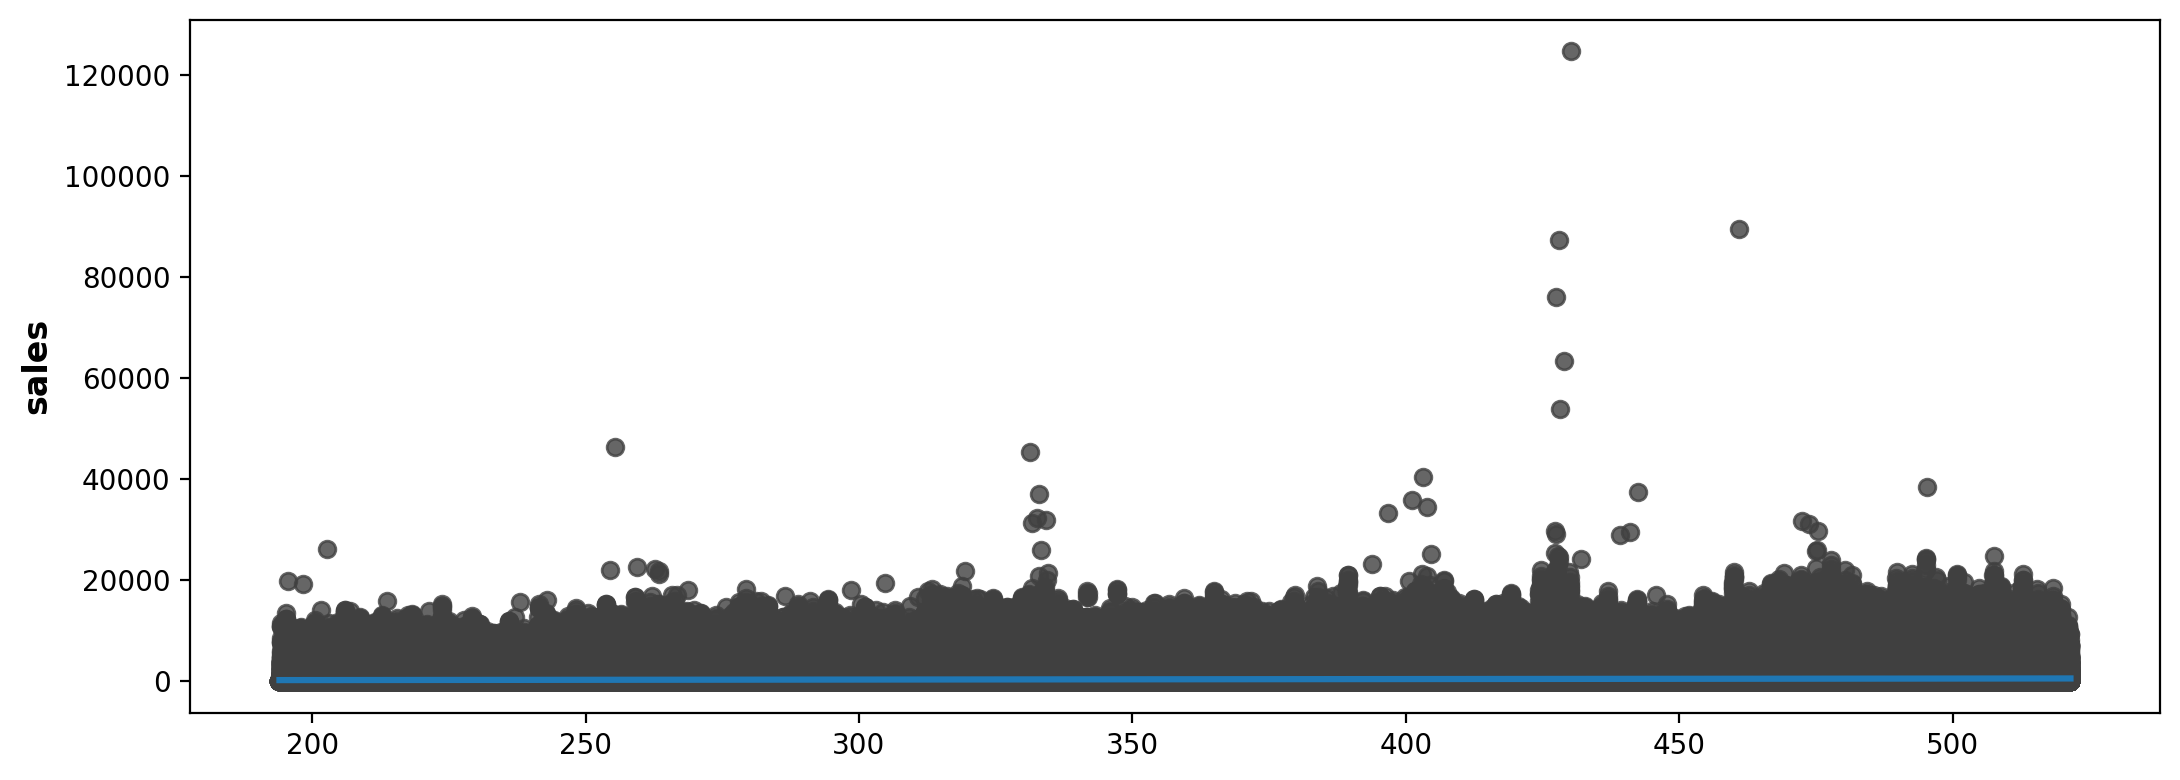

In [21]:
fig, ax = plt.subplots()
ax = sns.regplot(x=y_pred, y='sales', data=df, ci=None, scatter_kws=dict(color='0.25'))


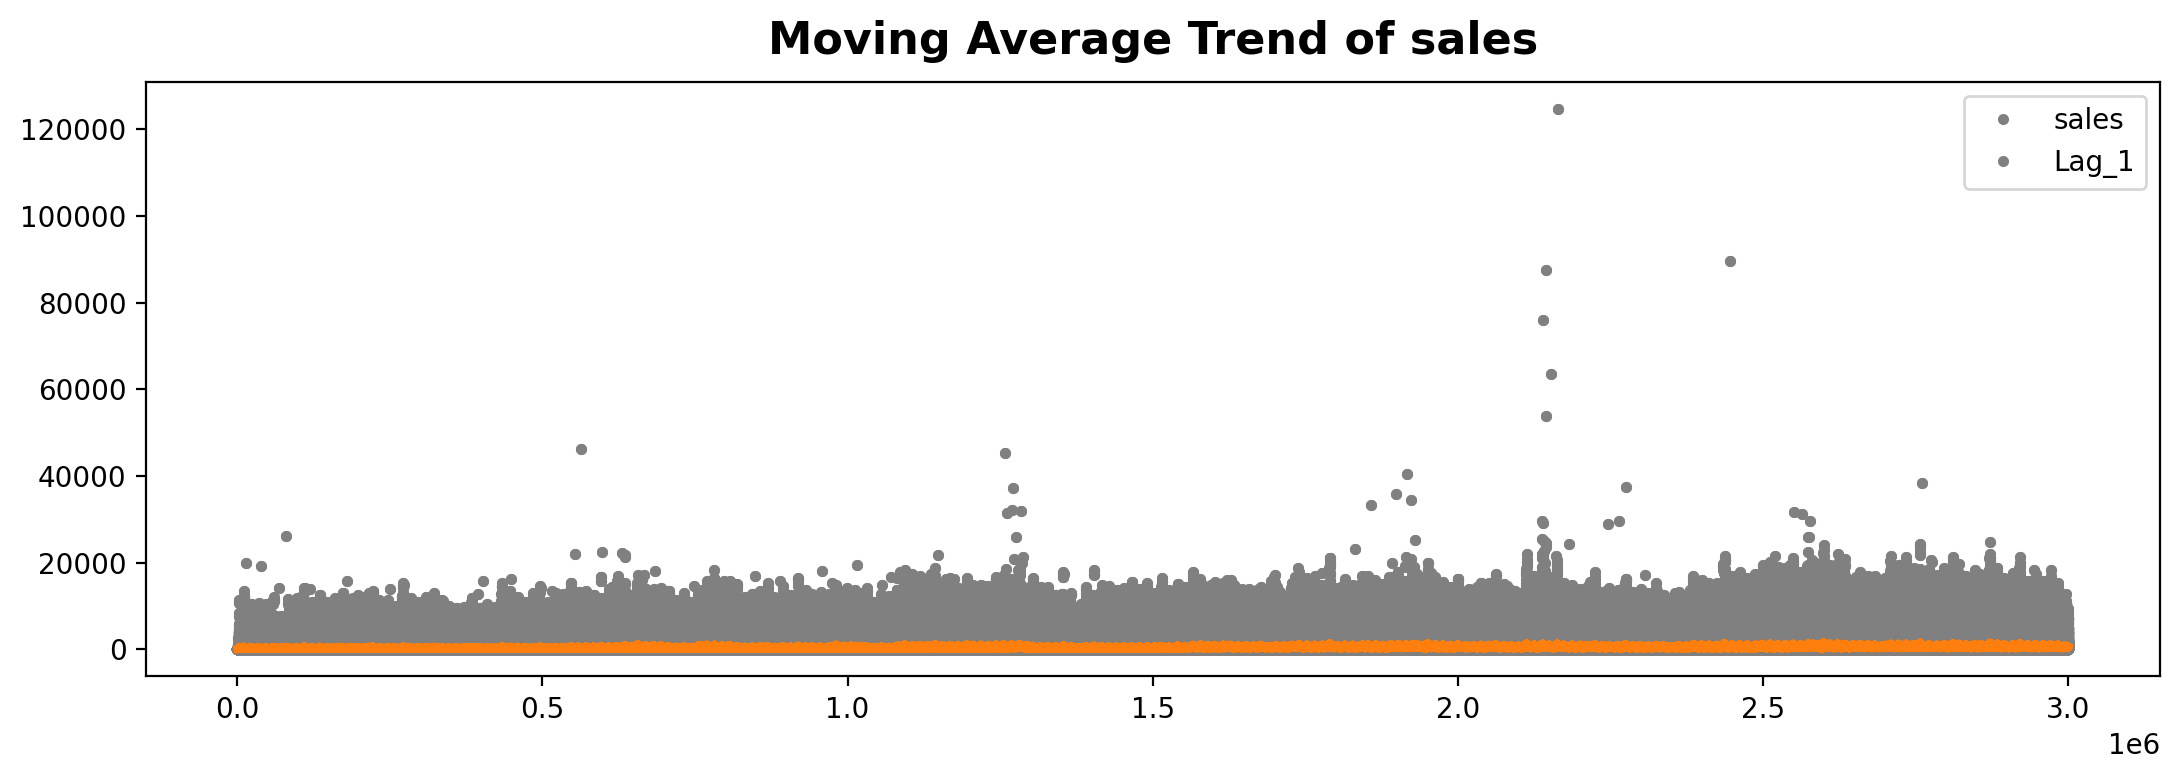

In [23]:
moving_average = df.rolling(
    window=365,       # 365-day window
    center=True,      # puts the average at the center of the window
    min_periods=183,  # choose about half the window size
).mean()              # compute the mean (could also do median, std, min, max, ...)

ax = df.plot(style=".", color="0.5")
moving_average.plot(
    ax=ax, linewidth=3, title="Moving Average Trend of sales", legend=False,
);

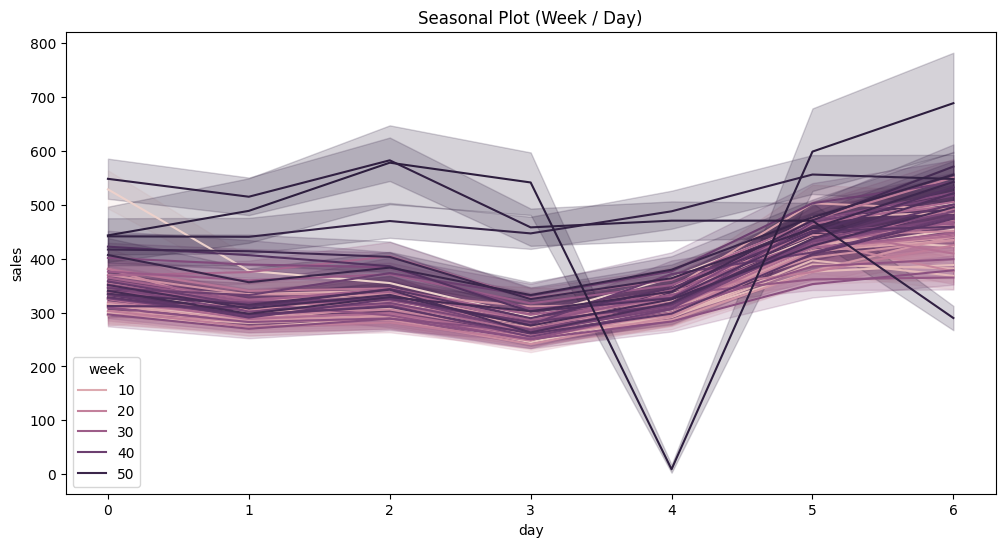

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df["date"] = pd.to_datetime(df["date"])
df["week"] = (df["date"].dt.isocalendar().week.astype(int))
df["day"] = df['date'].dt.dayofweek  # 0=Mon, ..., 6=Sun

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="day",
    y="sales",      # target column
    hue="week"
)

plt.title("Seasonal Plot (Week / Day)")
plt.show()

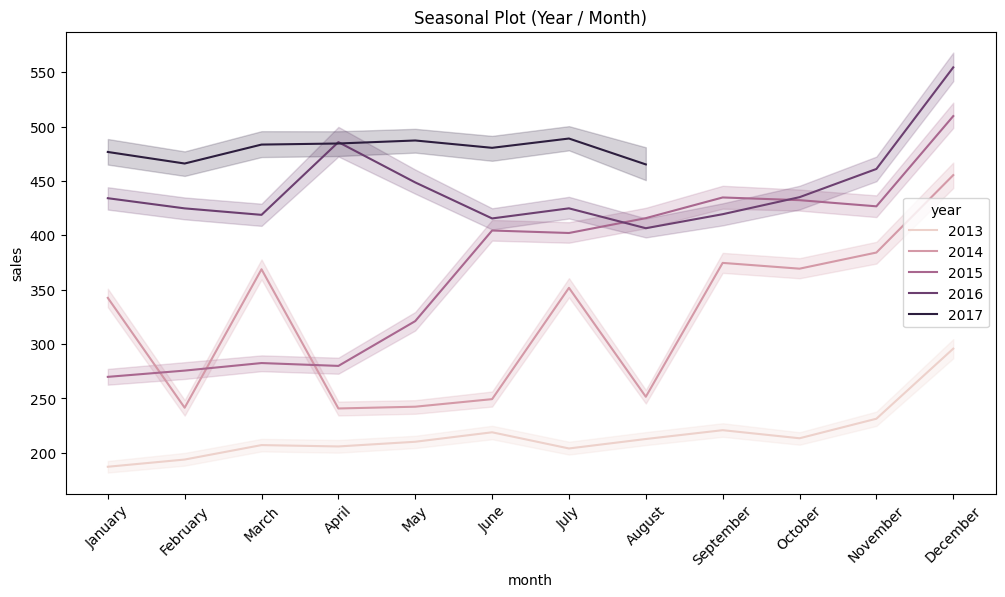

In [11]:
df["year"] = df["date"].dt.year

df["month"] = pd.Categorical(
    df["date"].dt.month_name(),
    categories=[
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ],
    ordered=True,
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="month",
    y="sales",  # target column
    hue="year"
)

plt.title("Seasonal Plot (Year / Month)")
plt.xticks(rotation=45)
plt.show()